# 6. The supplementary tier

<a href="https://colab.research.google.com/github/jmoortgat/GasBrineBench/blob/main/notebooks/06_supplementary_tier.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>


`supplementary/supplementary_measurements.csv` holds measurements that the benchmark families cannot store without a model, an assumed
density or an assumed pressure: apparent molar volumes, enthalpies of dilution, isopiestic pairs, Ostwald and Bunsen coefficients, and so on.
Values are as printed, in the unit of the paper; read `value_what` before using a class. This notebook shows what is there.

> **Running on Google Colab?** Click the badge above and run the cells; nothing needs to be installed. The first code cell detects
> Colab, clones the repository into `/content/GasBrineBench`, checks that pandas, numpy and matplotlib are present (Colab already has them)
> and changes into `notebooks/`, so everything after it works as on a local checkout. Locally the cell does nothing but confirm the layout.
> To use a fork or a branch, set `GBB_REPO_URL` and `GBB_BRANCH` before the cell runs.

In [1]:
# --- Colab / local bootstrap ---------------------------------------------------------------------------------
# On Colab this cell clones the repository and installs anything missing; on a local checkout it only confirms the layout.
# Re-running it is safe.
import os, subprocess, sys
from pathlib import Path

REPO_URL = os.environ.get("GBB_REPO_URL", "https://github.com/jmoortgat/GasBrineBench.git")
BRANCH = os.environ.get("GBB_BRANCH", "main")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB or os.environ.get("GBB_FORCE_BOOTSTRAP"):
    REPO_DIR = Path("/content/GasBrineBench") if IN_COLAB else Path(os.environ.get("GBB_CLONE_DIR", "GasBrineBench_clone")).resolve()
    if not REPO_DIR.exists():
        print(f"cloning {REPO_URL} ({BRANCH}) into {REPO_DIR}")
        subprocess.check_call(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f"repository already cloned at {REPO_DIR}")
    missing = []
    for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
        try:
            __import__(mod)
        except ImportError:
            missing.append(pkg)
    if missing:
        print("pip install -q", " ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    os.chdir(REPO_DIR / "notebooks")
    print("cwd =", os.getcwd())
else:
    print("local environment: using the existing checkout")

local environment: using the existing checkout


In [2]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
HERE = pathlib.Path.cwd()
ROOT = HERE if (HERE / "gasbrinebench").exists() else HERE.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "notebooks"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import gasbrinebench as gbb
from gasbrinebench.vocab import DEFAULT_EXCLUDED_FLAGS
import gbb_viz as V
V.style()
# default view (what a benchmark user scores) and the view that also keeps rows without a stated pressure
df = gbb.load()
dfp = gbb.load(exclude_flags=tuple(f for f in DEFAULT_EXCLUDED_FLAGS if f != "pressure-unstated"))
dfall = gbb.load(exclude_tags=None, exclude_flags=None)
print(f"{len(dfall):,} rows in total, {len(df):,} in the default view, gasbrinebench {gbb.__version__}")

26,815 rows in total, 23,090 in the default view, gasbrinebench 1.2.0


,rows,tables,sources,T_min,T_max
property_class,,,,,
isopiestic_pair,1367,24,18,298.2,498.2
gas_solubility_coefficient,966,16,7,274.0,308.2
apparent_molar_volume,706,7,5,273.2,368.2
gas_solubility_other_basis,520,21,13,268.2,760.2
enthalpy_of_dilution,391,5,5,288.2,674.1
density,358,7,5,277.2,473.2
mixture_volume,233,4,3,673.0,673.2
other,203,5,4,298.2,1123.2
compression,164,2,2,294.8,447.6


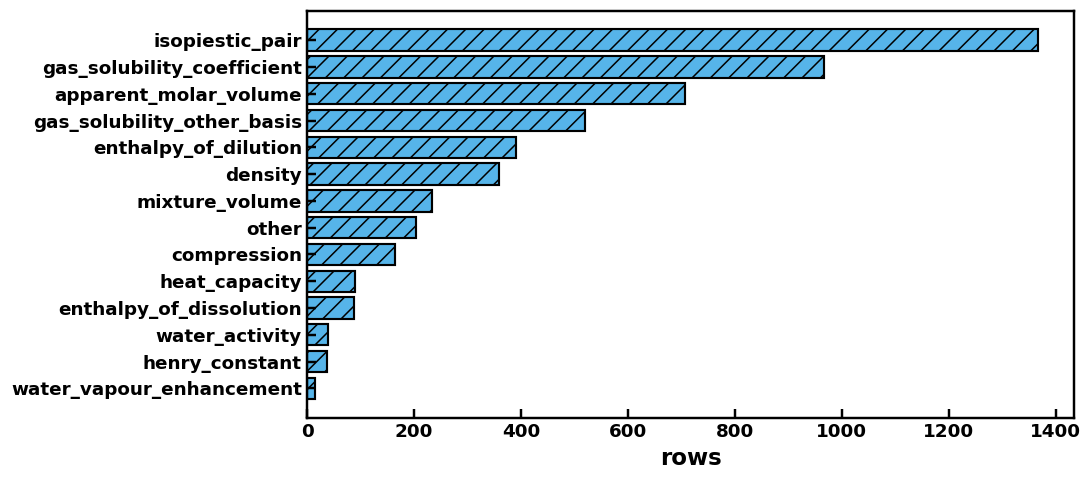

In [3]:
s = pd.read_csv(ROOT / "supplementary" / "supplementary_measurements.csv", keep_default_na=False)
for c in ["T_K", "P_bar", "value", "value2", "uncertainty"]:
    s[c] = pd.to_numeric(s[c], errors="coerce")
cls = s.groupby("property_class").agg(rows=("value", "size"), tables=("dataset_id", "nunique"), sources=("source", "nunique"), T_min=("T_K", "min"), T_max=("T_K", "max")).sort_values("rows", ascending=False)
display(cls.round(1))
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(cls.index[::-1], cls.rows[::-1], color="#56B4E9", edgecolor="black", linewidth=1.4, hatch="//"); V.lab(ax, "rows", ""); plt.show()

## Isopiestic pairs

Molality of a test solution against the molality of the reference salt (NaCl or KCl) in equilibrium with it, as printed. The osmotic
coefficient follows from the pair and a reference model; we leave that choice to the user.

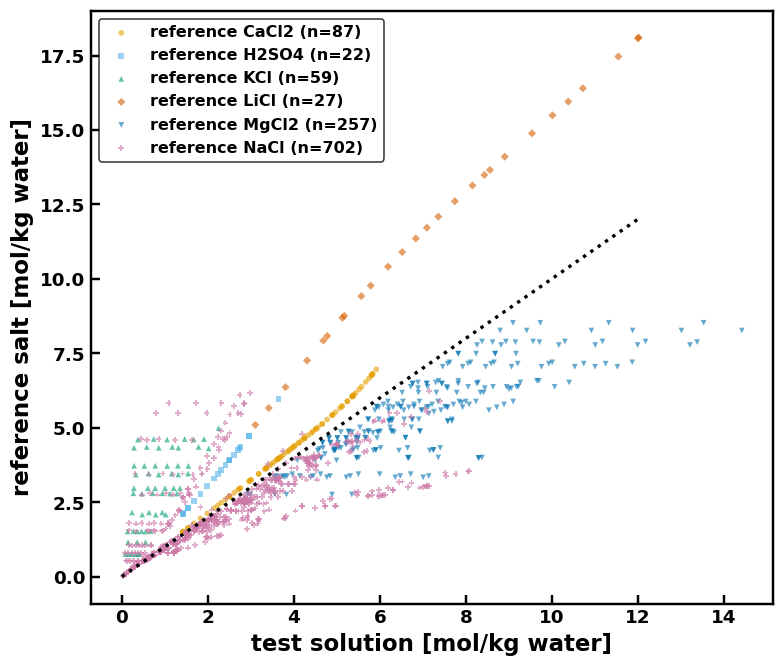

{'HOLMES(1994)': 288, 'RARD(1981b)': 130, 'BRENDLER(1996)': 127, 'HOLMES(1986)': 103, 'BRENDLER(1995)': 101, 'HOLMES(1978)': 78, 'ROBINSON(1966)': 69, 'HUMPHRIES(1968)': 58, 'ROBINSON(1968)': 57, 'BRENDLER(1994)': 29}


In [4]:
iso = s[s.property_class == "isopiestic_pair"].copy()
iso = iso[iso.value2.notna() & (iso.value > 0) & (iso.value2 > 0)]
iso["ref"] = iso.reference_salt.replace("", "?")
fig, ax = plt.subplots(figsize=(8, 7))
for k, (r, g) in enumerate(iso.groupby("ref")):
    ax.scatter(g.value, g.value2, s=14, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], alpha=0.6, edgecolor="none", label=f"reference {r} (n={len(g)})")
ax.plot([0, 12], [0, 12], color="black", ls=":"); ax.legend(); V.lab(ax, "test solution [mol/kg water]", "reference salt [mol/kg water]"); plt.show()
print(iso.groupby("source").size().sort_values(ascending=False).head(10).to_dict())

## Apparent molar volumes

{'CHEN(1977)': 566, 'CALL(2000)': 90, 'MOORE(1982)': 20, 'TIEPEL(1972)': 16, 'ENNS(1965)': 14}


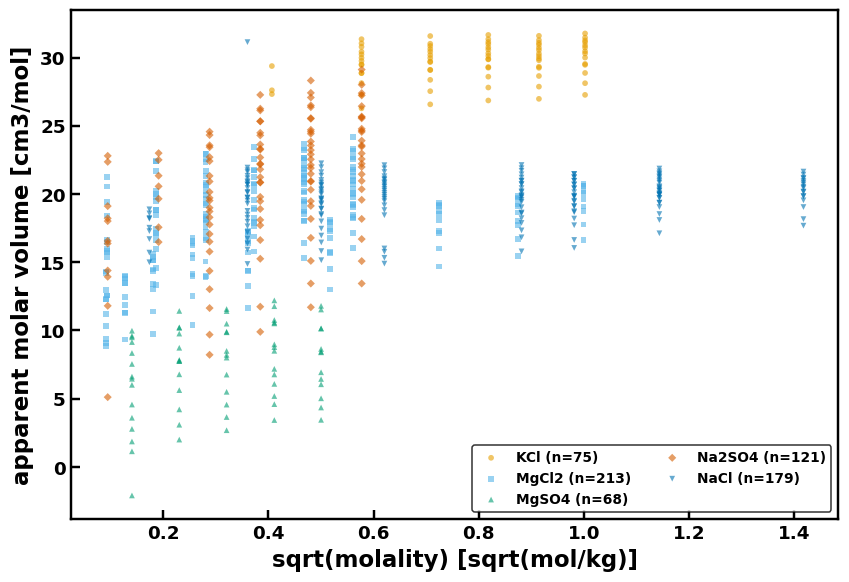

In [5]:
pv = s[s.property_class == "apparent_molar_volume"].copy()
print(pv.groupby("source").size().sort_values(ascending=False).to_dict())
g = pv[pv.solutes_mol_per_kg_water != ""].copy()
g["salt"] = g.solutes_mol_per_kg_water.str.split(":").str[0]
g["m"] = pd.to_numeric(g.solutes_mol_per_kg_water.str.split(":").str[1].str.split(";").str[0], errors="coerce")
fig, ax = plt.subplots(figsize=(9, 6))
for k, (salt, w) in enumerate(g[g.value_unit == "cm3/mol"].groupby("salt")):
    if len(w) < 10: continue
    ax.scatter(np.sqrt(w.m), w.value, s=14, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k % 12], alpha=0.6, edgecolor="none", label=f"{salt} (n={len(w)})")
ax.legend(ncol=2, fontsize=9); V.lab(ax, "sqrt(molality) [sqrt(mol/kg)]", "apparent molar volume [cm3/mol]"); plt.show()

## Enthalpy of dilution and gas-solubility coefficients

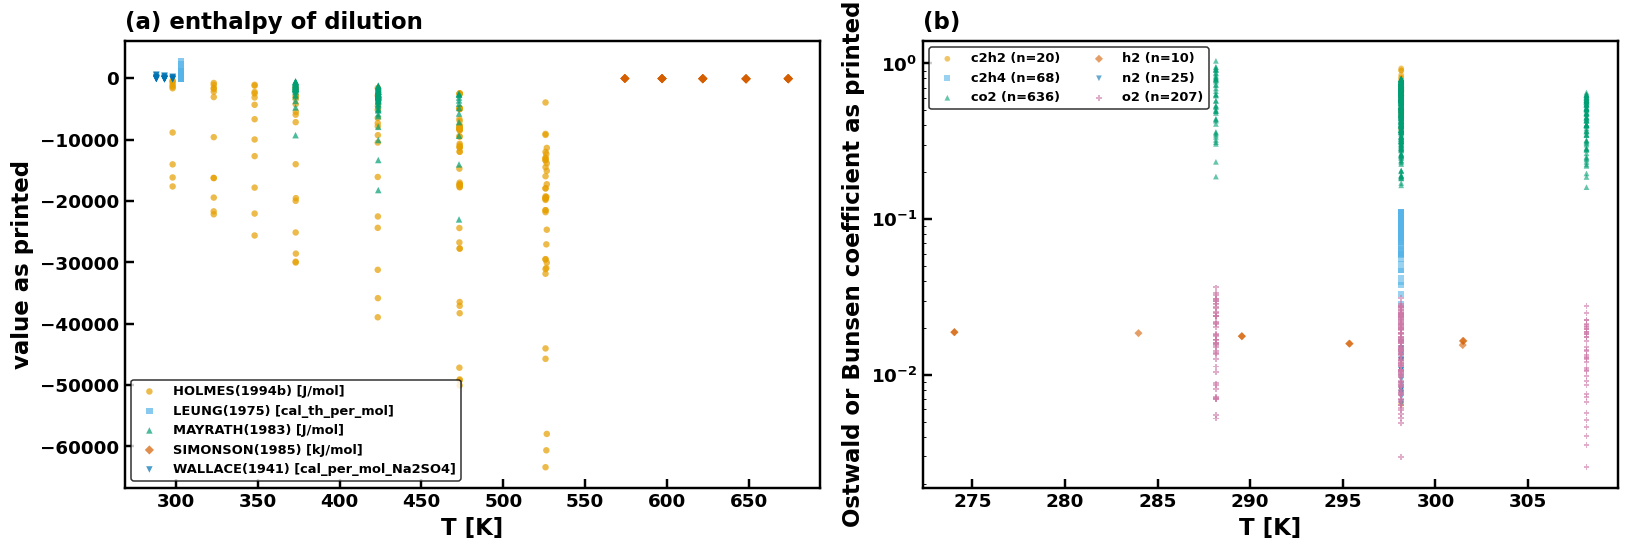

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
e = s[s.property_class == "enthalpy_of_dilution"]
for k, (src, w) in enumerate(e.groupby("source")):
    axes[0].scatter(w.T_K, w.value, s=18, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k], alpha=0.7, edgecolor="none", label=f"{src} [{w.value_unit.iloc[0]}]")
axes[0].legend(fontsize=8.5); V.lab(axes[0], "T [K]", "value as printed", "(a) enthalpy of dilution")
c = s[s.property_class == "gas_solubility_coefficient"]
for k, (g, w) in enumerate(c.groupby("gas")):
    axes[1].scatter(w.T_K, w.value, s=14, color=V.WONG[(k + 1) % 7], marker=V.MARKERS[k % 12], alpha=0.6, edgecolor="none", label=f"{g} (n={len(w)})")
axes[1].set_yscale("log"); axes[1].legend(ncol=2, fontsize=8.5); V.lab(axes[1], "T [K]", "Ostwald or Bunsen coefficient as printed", "(b)")
plt.tight_layout(); plt.show()